# IAT 461 — Assignment 4: Client Peer Project

## Context

### Entity

Kosima Production is a fictional video game development and player research company. The company studies player behaviour and public feedback to support decisions about game updates, technical improvements, and community communication. For this project, Kosima Production is examining Steam reviews of Cyberpunk 2077, an open-world role-playing game with a large and active player community. The company wants to understand why some players leave negative reviews and which concerns should receive the most attention.

### Business Context and Strategic Options

Cyberpunk 2077 has received a large number of Steam reviews containing feedback about technical performance, gameplay systems, story content, controls, and other parts of the player experience. The overall review score shows whether players recommend the game, but it does not clearly explain the reasons behind negative reviews.

Kosima Production is considering three possible strategies:
- Option A: Increase advertising and promotional activities to attract more players.
- Option B: Improve general community communication by publishing more announcements, development updates, and responses to player questions.
- Option C: Analyze negative Steam reviews to discover the technical and gameplay concerns that players mention most often, then use these findings to prioritize future improvements.


### Task

#### Phase 1, EDA and Strategy Validation

Using the structured review data, examine player recommendation outcomes, playtime, helpfulness votes, review dates, purchase status, reviewer experience, and other available variables. Determine whether negative reviews are mainly connected to limited communication, certain types of players, particular time periods, or repeated technical and gameplay concerns. Use the results to evaluate Options A, B, and C and identify which strategy is best supported by the data.

#### Phase 2, Data Science Implementation

Assuming Kosima Production proceeds with Option C, group the English-language negative reviews according to their underlying complaint themes. The analysis should not begin with a predefined list of issue categories. Instead, the themes should be discovered from similarities in the language used in the reviews.

After creating the groups, compare them using the number of reviews, percentage of negative reviews, median player playtime, review length, helpfulness votes, purchase status, and reviewer experience. Use these comparisons to determine which complaint themes should receive the highest priority.


## Imports

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk

from spacy.lang.en.stop_words import STOP_WORDS
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud

# classification + clustering

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Initial Steps

### Loading Dataset

We will first take a look at the dataset our client provided for us.

In [11]:
df = pd.read_csv("Cyberpunk_2077_English_Reviews_Final.csv")
df.head(5)

,ReviewID,SteamID,Rating,Review,Date Posted,Hours Played,Voted Helpful,Received for Free,Update,Detected Language
0,81918897,Rommel,Recommended,"""Hᴇ's ғᴜᴄᴋᴇᴅ ɪɴ ᴛʜᴇ ʜᴇᴀᴅ, ᴛʜᴇ ᴡᴏʀʟᴅ's ғᴜᴄᴋᴇᴅ ɪ...",12/9/2020,401.5,22,False,Release,en
1,81918903,76561198038931832,Recommended,It's a city of dreams... and I'm a big dreamer.,12/9/2020,247.6,710,True,Release,en
2,81918912,limbo97,Recommended,Obligatory It's breathtaking!A wonderful sci-f...,12/9/2020,8.8,19,False,Release,en
3,81918918,sn1ffla,Not Recommended,"Bigot developerTo clarify, I got this game fro...",12/9/2020,86.1,18,True,Release,en
4,81918924,MeliGL,Recommended,Still waiting to be able to play.Edit: I'm not...,12/9/2020,34.9,0,False,Release,en


### Inspecting the Data

Next, we'll be inspecting the data for their types, structure, and any missing values.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ReviewID           365388 non-null  int64 
 1   SteamID            365388 non-null  object
 2   Rating             365388 non-null  object
 3   Review             362569 non-null  object
 4   Date Posted        365388 non-null  object
 5   Hours Played       365388 non-null  object
 6   Voted Helpful      365388 non-null  object
 7   Received for Free  365388 non-null  bool  
 8   Update             365388 non-null  object
 9   Detected Language  365388 non-null  object
dtypes: bool(1), int64(1), object(8)
memory usage: 25.4+ MB


Seems like we're only missing a few thousand reviews. We'll keep these in for now as the extra data is helpful and filter them out later during our text processing.

In [16]:
df.sample(5)

,ReviewID,SteamID,Rating,Review,Date Posted,Hours Played,Voted Helpful,Received for Free,Update,Detected Language
364147,171980604,2134142345,Recommended,game has aura,12-Aug-24,321.7,2,False,Patch 2.12,en
112716,82725245,76561198065439909,Recommended,Game has a few bugs but nothing not worth play...,12/19/2020,132.3,0,False,Hotfix 1.05,en
50062,82180828,76561198986337177,Recommended,"I love the game so far, haven't gotten too far...",12/12/2020,320.5,0,False,Hotfix 1.04,en
72481,82322572,Its_Sam,Recommended,If you have good hardware it is a genuinely go...,12/13/2020,155.7,0,False,Hotfix 1.04,en
219706,110099729,76561198157140094,Recommended,"If you have a beefy graphics card, go for it. ...",2/12/2022,49.5,0,False,Patch 1.31,en


Let's just make sure everything is in English:

In [18]:
df["Detected Language"].value_counts()

Detected Language
en    365388
Name: count, dtype: int64

And then looking at the balance of our ratings:

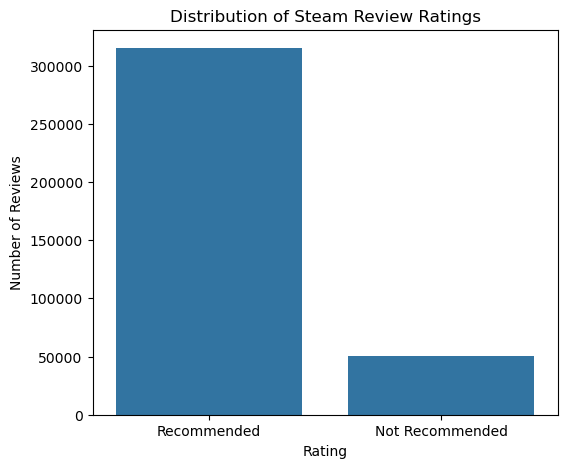

In [20]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Rating"
)

plt.title("Distribution of Steam Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [21]:
rating_percent = (
    df["Rating"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(rating_percent)

Rating
Recommended        86.21
Not Recommended    13.79
Name: proportion, dtype: float64


We are working with an unbalanced dataset.

### Data Conversion

Let's just quickly update the fields `Hours Played` and `Voted Helpful` to the right data types:

In [25]:
df["Hours Played"] = (
    df["Hours Played"]
      .str.replace(",", "")
      .astype(float)
)

df["Voted Helpful"] = (
    df["Voted Helpful"]
      .str.replace(",", "")
      .astype(int)
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ReviewID           365388 non-null  int64  
 1   SteamID            365388 non-null  object 
 2   Rating             365388 non-null  object 
 3   Review             362569 non-null  object 
 4   Date Posted        365388 non-null  object 
 5   Hours Played       365388 non-null  float64
 6   Voted Helpful      365388 non-null  int32  
 7   Received for Free  365388 non-null  bool   
 8   Update             365388 non-null  object 
 9   Detected Language  365388 non-null  object 
dtypes: bool(1), float64(1), int32(1), int64(1), object(6)
memory usage: 24.0+ MB


Since our brief wants us to:

> Determine whether negative reviews are mainly connected to limited communication, certain types of players, **particular time periods**, or repeated technical and gameplay concerns.

We'll go ahead and convert `Date Posted` to datetime in anticipation of working with dates.

In [27]:
df["Date Posted"] = pd.to_datetime(
    df["Date Posted"],
    format="mixed", # this dataset has mixed formats I had found
    errors="coerce"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ReviewID           365388 non-null  int64         
 1   SteamID            365388 non-null  object        
 2   Rating             365388 non-null  object        
 3   Review             362569 non-null  object        
 4   Date Posted        365388 non-null  datetime64[ns]
 5   Hours Played       365388 non-null  float64       
 6   Voted Helpful      365388 non-null  int32         
 7   Received for Free  365388 non-null  bool          
 8   Update             365388 non-null  object        
 9   Detected Language  365388 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(1), int32(1), int64(1), object(5)
memory usage: 24.0+ MB


We'll also quickly add some other useful date times:

In [29]:
df["Year"] = df["Date Posted"].dt.year
df["YearMonth"] = df["Date Posted"].dt.to_period("M")

monthly_reviews = (
    df.groupby("YearMonth")
      .size()
      .reset_index(name="Reviews")
)

print(monthly_reviews.head())

  YearMonth  Reviews
0   2020-12   148492
1   2021-01    21754
2   2021-02     5721
3   2021-03     4665
4   2021-04     3931


## Assumptions Log

Based on the given dataset and the task at hand, I continued on with the following assumptions:

**Hours Played is used as a proxy for "reviewer experience"**

The dataset doesn't contain a direct measure of "reviewer experience", so we are using `Hours Played`, which is a measure of experience with the game.

**Communication**

The dataset doesn't contain a direct measure of communication from the developers, like announcements, exposure to the playerbase, and player responses, so we will be basing it off of changes of sentiment over time instead, which I assume that developers continued a normal amount of communication to players.

**Advertising**

We are going to evaluate Option A indirectly through player characteristics and review outcomes as we do not have data on advertising or player-acquisition data.

These are all due to the limitations of the given dataset. 

## Phase 1: EDA and Strategy Validation

> Using the structured review data, examine player recommendation outcomes, playtime, helpfulness votes, review dates, purchase status, reviewer experience, and other available variables. Determine whether negative reviews are mainly connected to limited communication, certain types of players, particular time periods, or repeated technical and gameplay concerns. Use the results to evaluate Options A, B, and C and identify which strategy is best supported by the data.

### Review Timeline

Using the `Date Posted` field, we can just look through how reviews for the game look like throughout the months.

#### Reviews Over Time

First, let's get te total reviews over time.

In [38]:
monthly_reviews = (
    df.groupby("YearMonth")
      .size()
      .reset_index(name="Reviews")
)

monthly_reviews["YearMonth"] = monthly_reviews["YearMonth"].astype(str)

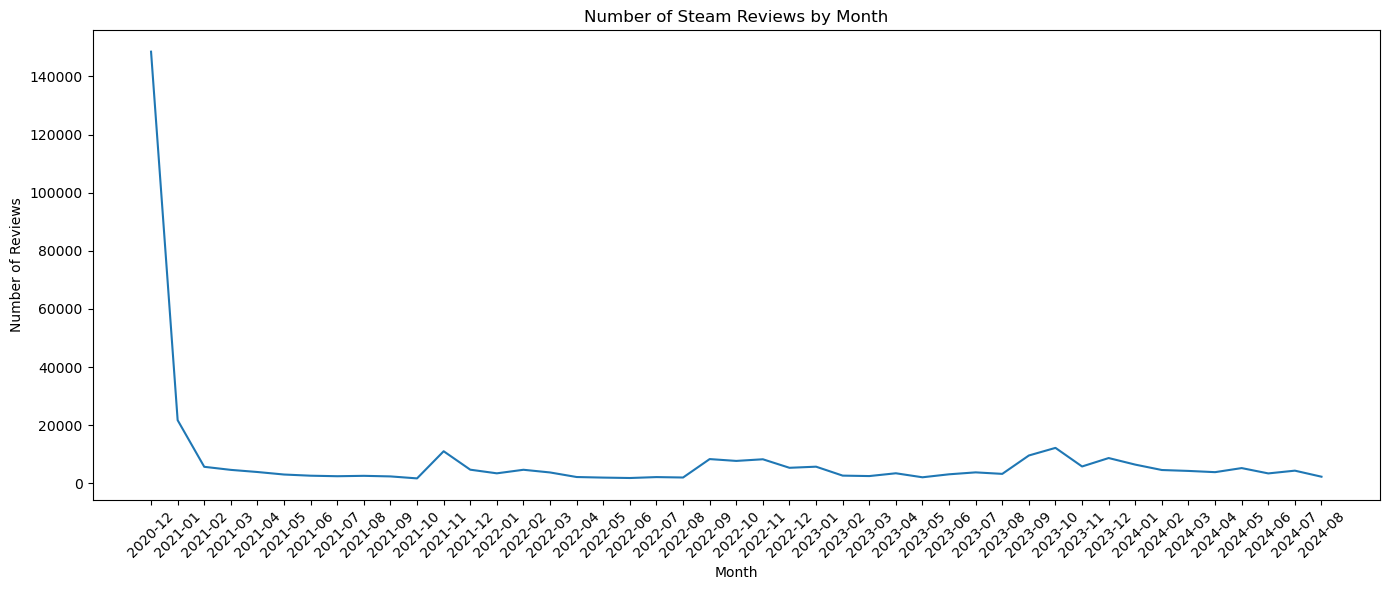

In [39]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_reviews["YearMonth"],
    monthly_reviews["Reviews"]
)

plt.xticks(rotation=45)

plt.title("Number of Steam Reviews by Month")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

This shows that most reviews were written after launch, and trends upwards around November 2021, August 2022, and October 2023. Let's take a look at what patch these are:

In [41]:
df.loc[df["YearMonth"] == "2021-11", "Update"].value_counts()

Update
Patch 1.31    11071
Name: count, dtype: int64

Comes after one of the ["most significant update for the game yet"](https://www.notebookcheck.net/Cyberpunk-2077-Patch-1-3-is-the-most-significant-update-for-the-game-yet-with-over-33-GB-of-fixes-changes-and-improvements.555775.0.html). 

In [43]:
df.loc[df["YearMonth"] == "2022-09", "Update"].value_counts()

Update
Patch 1.6     8120
Patch 1.52     256
Name: count, dtype: int64

This set of reviews come after the [Cyberpunk: Edgerunners](https://www.cyberpunk.net/en/news/45280/edgerunners-update-patch-1-6-list-of-changes) update. This is a separate anime based on the game that possibly brought in new players to the game.

In [45]:
df.loc[df["YearMonth"] == "2023-10", "Update"].value_counts()

Update
Patch 2.01    8070
Patch 2.0     2690
Patch 2.02    1470
Name: count, dtype: int64

This set of reviews come after the [2.0 updates](https://expertgamereviews.com/cyberpunk-2077-2-update-complete-guide/). We can take a closer look by checking the positive vs. negative reviews over time:

#### Positive vs Negative over time

In [48]:
monthly_rating = (
    df.groupby(["YearMonth", "Rating"])
      .size()
      .unstack(fill_value=0)
)

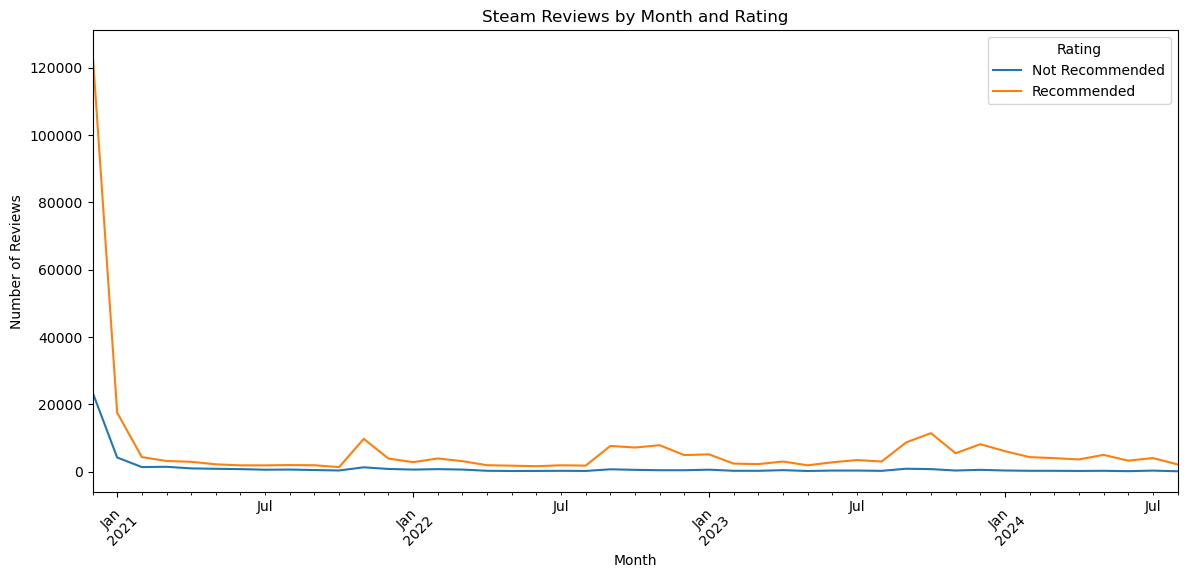

In [49]:
monthly_rating.plot(
    figsize=(14,6)
)

plt.title("Steam Reviews by Month and Rating")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

Overall, it looks like the negative reviews remained flat all throughout the time periods. There's a huge chunk at release, but the uptick in reviews seem to be positive in the ones we've identified above. Let's zoom in to take a closer look at the ratings:

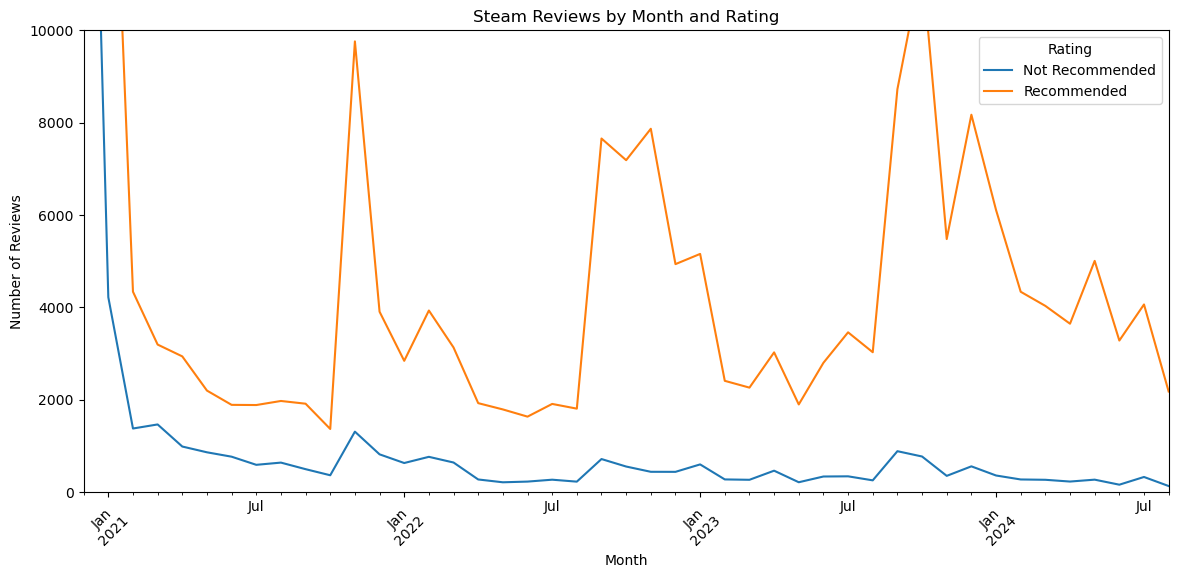

In [51]:
monthly_rating.plot(
    figsize=(14,6)
)

plt.title("Steam Reviews by Month and Rating")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.ylim(0, 10000) # set y limit to "zoom" in

plt.xticks(rotation=45)

plt.show()

Those trends in reviews we identified earlier (from certain updates) seem to be mostly positive reviews. Each wave of positive reviews come with a wave of negative reviews as well, however.

#### Percent of Negative Reviews

By looking at the percent of negative reviews to the rest of it, we can get a better picture of user sentiment throughout time.

In [54]:
monthly_counts = (
    df.groupby(["YearMonth", "Rating"])
      .size()
      .unstack(fill_value=0)
)

monthly_percent = monthly_counts.div(
    monthly_counts.sum(axis=1),
    axis=0
) * 100

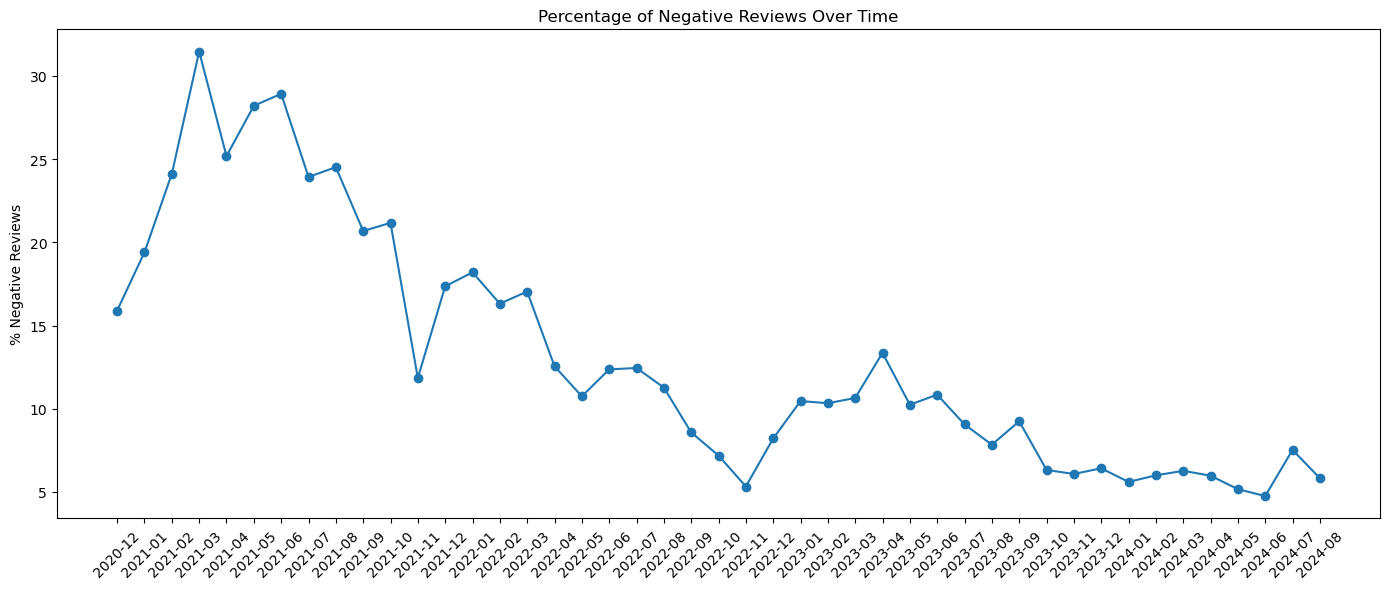

In [55]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_percent.index.astype(str),
    monthly_percent["Not Recommended"],
    marker="o"
)

plt.xticks(rotation=45)
plt.ylabel("% Negative Reviews")
plt.title("Percentage of Negative Reviews Over Time")
plt.tight_layout()
plt.show()

It looks like negative reviews (compared to positive reviews) percentage generally decrease over time with the exception of early release, December 2021, and May 2023. However, the graph above this one shows a more constant stream of negative reviews, meaning that rather than negative reviews dropping, positive reviews just overwhelm the percentages.

#### Interpretation and Analysis

Based on these findings, we see that negative reviews remain consistent throughout time, with the exception of major patches and releases (which end up stabilizing anyway). There were the most negative reviews upon launch, but generally trend downwards throughout time. With this in mind, let's evaluate the options so far:

**Option A - Advertising**: As negative reviews generally decrease over time, attracting more players would possibly result in more positive reviews. We can see this in the Cyberpunk: Edgerunners patch in Fall 2022. However, it is unclear whether or not attracting new players to the game would help us understand why some players leave negative reviews.

**Option B - Communication**: Our findings show that user sentiment to the game (through the percentage of Negative Reviews Over Time) decrease over time, especially after the hotfixes after major releases. It's likely that learning about bugs and fixing them right away lead to more player satisfaction, meaning we should consider Option B more closely.

**Option C - Complaint Analysis**: Unclear so far.

### Player Characteristics

We can take a look at the characteristics of the players (playtime & if they received the game for free).

#### Hours Played vs Rating

First, let's quickly just look at the summary statistics for `Hours Played`.

In [61]:
df.groupby("Rating")["Hours Played"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,90.597130,171.010862,0.0,21.1,56.0,112.1,16052.3
Recommended,315005.0,163.536008,264.924241,0.1,62.0,111.2,193.9,29823.0


As one would expect, there are less hours played for those who do not recommend the game. There's a median of 56 hours for those who do not recommend the game, while there's a median of 111.2 for those who do recommend the game. 

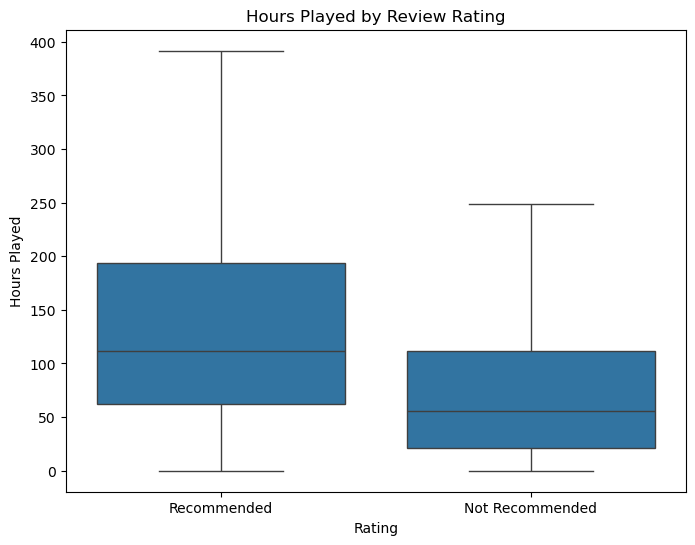

In [63]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Rating",
    y="Hours Played",
    showfliers=False # remove outliers to show the box more clearly
)

plt.title("Hours Played by Review Rating")
plt.ylabel("Hours Played")

plt.show()

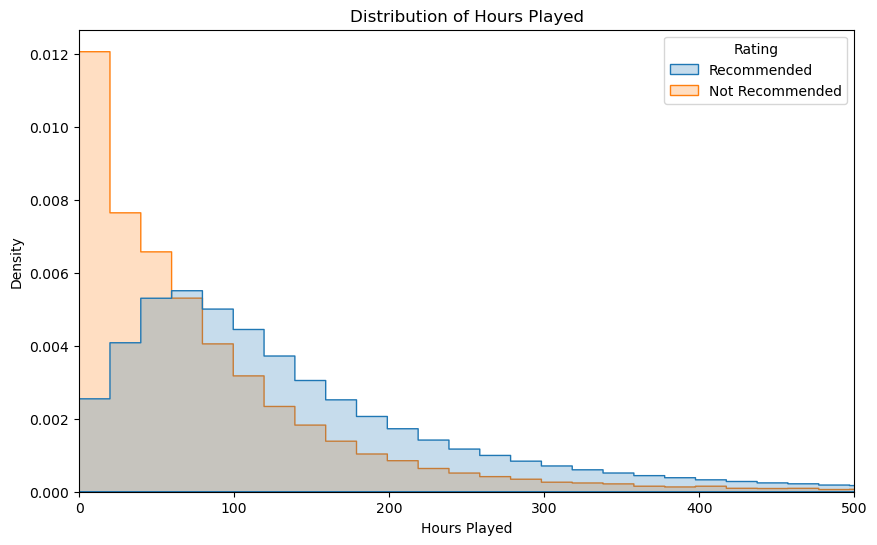

In [64]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Hours Played",
    hue="Rating",
    bins=1500,
    stat="density",
    common_norm=False,
    element="step"
)

plt.xlim(0,500)

plt.title("Distribution of Hours Played")

plt.show()

Above is a density plot of hours played vs. whether or not they recommend the game. As shown in the chart, more players who do not recommend the game tend to have lower playtimes, more specifically in the 0-60 hour mark. As players play more of the game, they tend to leave a more positive review.

Both distributions are right-skewed. This means that most players, regardless of rating, have low playtime.

#### Purchase Status / Received for Free

We can also take a look at each player's purchase status for this game. Do players who receive the game tend to leave a more favourable review?

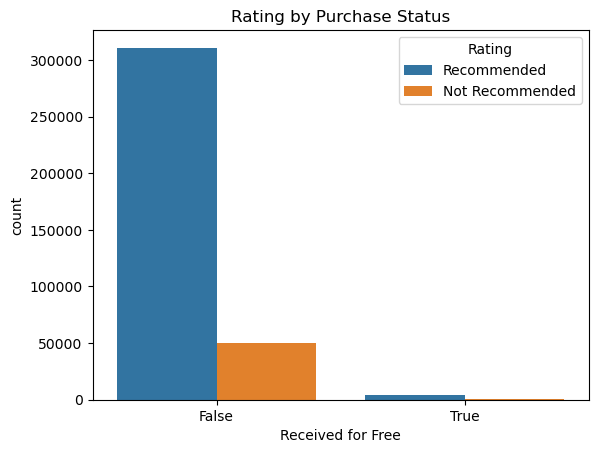

In [67]:
sns.countplot(
    data=df,
    x="Received for Free",
    hue="Rating"
)

plt.title("Rating by Purchase Status")
plt.show()

It's a bit hard to read, so we'll pivot to a percentage-based view of the data:

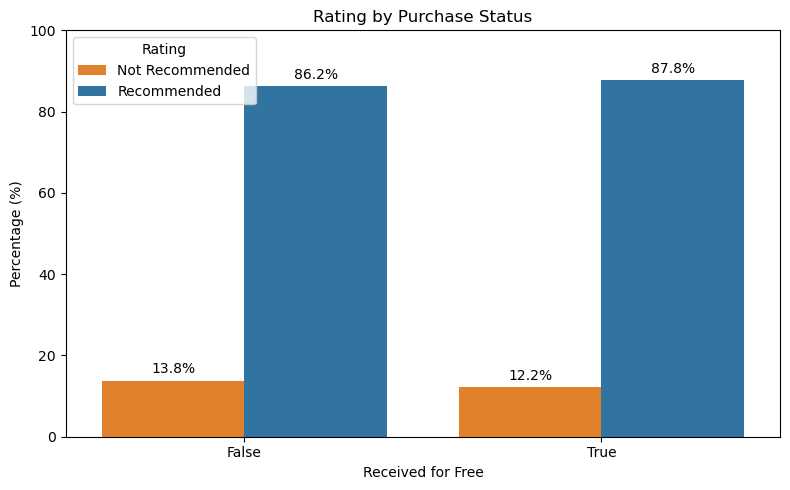

In [69]:
# Calculate percentages
percent_df = (
    pd.crosstab(
        df["Received for Free"],
        df["Rating"],
        normalize="index"
    ) * 100
).reset_index().melt(
    id_vars="Received for Free",
    var_name="Rating",
    value_name="Percentage"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=percent_df,
    x="Received for Free",
    y="Percentage",
    hue="Rating",
    palette=["tab:orange", "tab:blue"]  # Flipped colors
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.ylabel("Percentage (%)")
plt.xlabel("Received for Free")
plt.title("Rating by Purchase Status")
plt.ylim(0, 100)
plt.legend(title="Rating")

plt.tight_layout()
plt.show()

It seems that there isn't too much of a difference if a player received the game for free or not. There is only a 1.6% difference between the not recommended reviews out of the whole. 

#### Interpretation and Analysis

Based on these findings, we see that the distribution for playtime is right skewed, meaning that most players play under 100 hours. The distribution for those who do not recommend the game fall mostly between 0-60 hours, whereas those who do recommend the game fall mostly between 60-100 hours and in higher playtimes. We also find that there isn't an observable difference between purchase status or not whether or not they recommend the game or not in their reviews. With this in mind, let's evaluate the options so far:

**Option A: Advertising**: Not strongly supported, as negative reviews are more likely to come from players with lower playtime. Attracting more players could potentially result in more players encountering the same issues that lead to negative reviews. The lack of a noticeable difference based on whether or not players received the game for free suggests that price isn't a primary concern them players. Therefore, increasing the number of players does not seem to address the problems that lead to negative reviews.

**Option B: Communication**: Improving communication also is not strongly supported. Although the data shows that there's a difference in playtime between those who leave positive and negative reviews, playtime alone doesn't indicate whether or not communication is the reason for this difference. Since purchase status doesn't seems to have a relationship whether or not the player gives a positive or a negative review, there isn't really much evidence that shows changing how the company communicates with the players would fix player dissatisfaction. 

**Option C: Complaint Analysis**: Most promising option, but seeing these player characteristics is not enough. The difference in playtime might mean that some players encounter problems relatively early in game, but we still would have no idea what those problems are. Checking out the language in the negative reviews might lead to more direct evidence about game issues.

### Review Characteristics

Next, we'll take a look at the the characteristics of the reviews (helpful votes, length, correlations, etc.).

#### Review Length

Longer reviews usually mean that the feedback is more detailed, while shorter ones might just be approval or disapproval. We can create this feature and compare between recommended and not recommended reviews.

In [75]:
# Create review length

df["Review Length"] = (
    df["Review"]
      .fillna("")
      .str.split()
      .str.len()
)

In [76]:
df.groupby("Rating")["Review Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,88.536213,168.149093,0.0,7.0,28.0,92.0,1572.0
Recommended,315005.0,44.353601,108.025052,0.0,2.0,11.0,38.0,2000.0


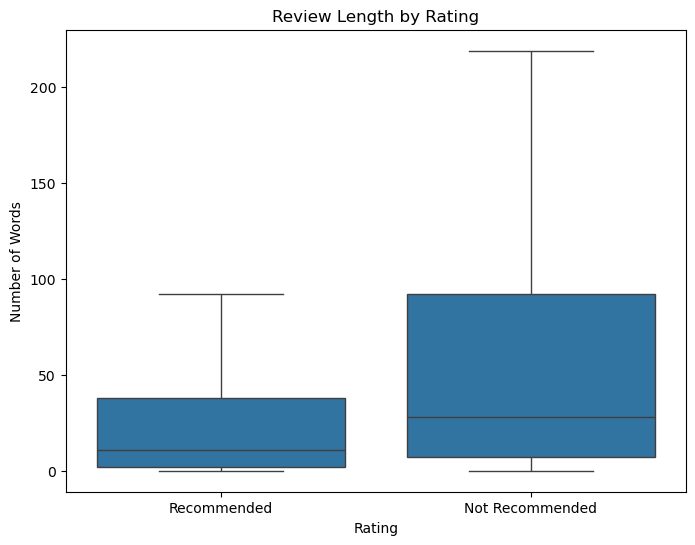

In [77]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Rating",
    y="Review Length",
    showfliers=False  # remove outliers to show the box more clearly
)

plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Words")

plt.show()

Looking at the distribution, it seems like it is right skewed. It seems that the recommended reviews are shorter in general with a lower average and median. This makes sense as negative reviews would provide more detailed explanations for their dissatisfaction of the game.

#### Helpful Votes

Taking a look at the reviews' helpful votes can let us know if they are useful or not.

In [80]:
df.groupby("Rating")["Voted Helpful"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,5.474009,125.068857,0.0,0.0,1.0,2.0,12367.0
Recommended,315005.0,1.561426,69.781851,0.0,0.0,0.0,1.0,20111.0


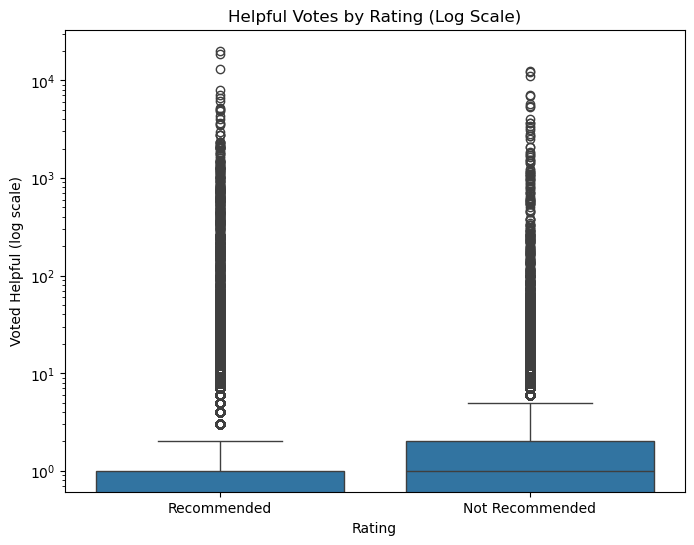

In [81]:
plt.figure(figsize=(8,6))

ax = sns.boxplot(
    data=df,
    x="Rating",
    y="Voted Helpful"
)

ax.set_yscale("log") # set to log scale to make it easier to read

plt.title("Helpful Votes by Rating (Log Scale)")
plt.ylabel("Voted Helpful (log scale)")
plt.show()

It seems that negative reviews receive more helpful votes on average, meaning that other players find these reviews more informative. However, a majority of the reviews are low anyway. 

#### Review Length vs Helpful Votes

We can take a look at whether or not helpful votes correlate with the review length. Does a longer review result in a more helpful review?

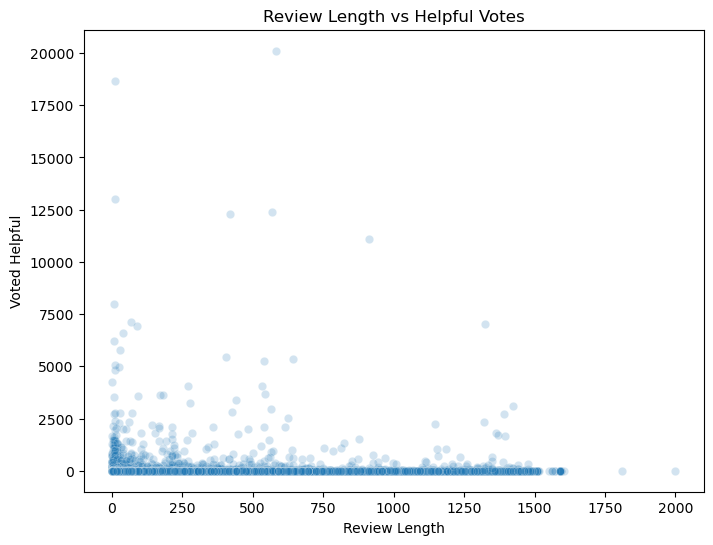

In [84]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Review Length",
    y="Voted Helpful",
    alpha=0.2
)

plt.title("Review Length vs Helpful Votes")

plt.show()

Doesn't look like much. Let's zoom in on that cluster at the bottom left to make sure:

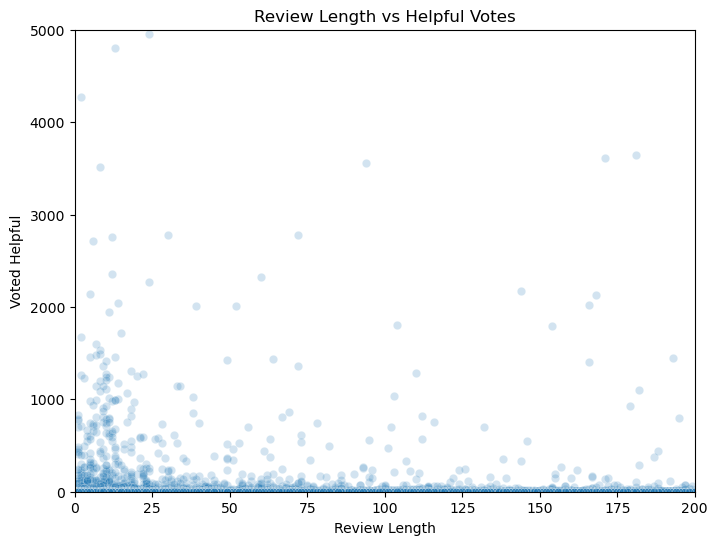

In [86]:
plot_df = df[
    (df["Voted Helpful"] <= 5000) &
    (df["Review Length"] <= 200)
]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="Review Length",
    y="Voted Helpful",
    alpha=0.2
)

plt.title("Review Length vs Helpful Votes")
plt.xlim(0, 200)
plt.ylim(0, 5000)

plt.show()

There doesn't seem to be much correlation between the two as most reviews sit at 0 helpful votes. The top reviews seem to just be short and sweet. Out of curiosity, let's take a look:

In [88]:
df.loc[
    df["Voted Helpful"] > 12000,
    ["Voted Helpful", "Review"]
].sort_values("Voted Helpful", ascending=False)

,Voted Helpful,Review
4033,20111,DOWNLOAD THE NVIDIA GAME READY DRIVERS FOR THE...
94,18652,They made a 18+ gameThey also waited for every...
131251,13022,Just remember:Angel is a dude.Skye is a chick....
5122,12367,All the negative reviews thus far are about th...
176883,12286,Everyone complained about the bugs and glitche...


That's a very helpful top review.

#### Correlation between Numeric Features

Now let's just take in all of the numeric features and just look at the correlation matrix:

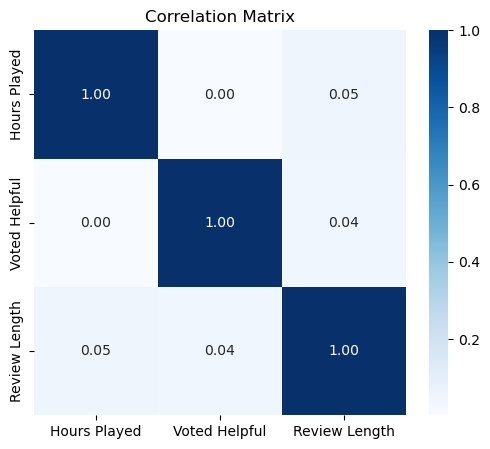

In [91]:
numeric = df[[
    "Hours Played",
    "Voted Helpful",
    "Review Length"
]]

corr = numeric.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

There does not seem to be a correlation whatsoever between `Hours Played`, `Voted Helpful`, and `Review Length`.

#### Interpretation and Analysis

Based on these findings, we see that there is an increase in review length for negative reviews than positive ones, probably due to the fact that these negative reviews have more to say than the positive ones. We also find that there are litle to no correlation between `Hours Played`, `Voted Helpful`, and `Review Length`. This information doesn't really do much for either of the first two options, but since the negative reviews are more detailed/lengthy, we can have much more to work with for Option C if we decide to go with it.

### Negative Review Text

To get started on determining if Option C is viable, we need to do a bit of NLP. We need to see if there are any recurring complaint themes that are worth analyzing.

In [96]:
# Get the negative reviews that aren't empty 

negative_reviews = df[(df["Rating"] == "Not Recommended") & (df["Review"].notna())].copy()

print(len(negative_reviews))

50234


We have 50234 total reviews we can work with.

#### Text Preprocessing

In [99]:
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [
        word for word in text.split()
        if word not in stop_words
    ]
    return words

In [100]:
negative_reviews["tokens"] = (
    negative_reviews["Review"]
    .apply(preprocess)
)

#### Text Processing

Using nltk and regular expressions and spacy and custom stopwords (shoutout to my LING special topics class that we did NLP in), we can get the 20 most common words in our negative reviews.

I had updated the stopwords list as I went through with this section. The following words in the stopword list are words I thought were unhelpful to our purpose here. Through this filtering, I was able to get more helpful results.

In [102]:
custom_stopwords = {
    "game", "games", "play", "played", "playing",
    "player", "players", "steam",
    "like", "get", "got", "one",
    # other terms I found would help narrow down the search
    "cd", "project", "projekt", "red", "reddit", 
    "youtube", "www", "com", "http", "https",
    "cyberpunk", "keanu", "deus", "theft",
    "crashedgame", "gta", "fallout",
    # I seem to not have done my tokenizing correctly so I just added the contractions into my stopwords
    "t", "s", "m", "ve", "re", "ll", "d",
    "don", "doesn", "didn", "isn", "aren",
    "wasn", "weren", "won", "would", "could",
    "also", "really", "even"
}

stop_words = list(STOP_WORDS | custom_stopwords)

#### Word Counts

In [104]:
all_words = [
    word
    for tokens in negative_reviews["tokens"]
    for word in tokens
    if word not in stop_words
]

word_counts = Counter(all_words)

word_counts.most_common(20)

[('story', 17246),
 ('bugs', 17219),
 ('good', 12205),
 ('time', 11879),
 ('world', 10909),
 ('character', 7641),
 ('bad', 7537),
 ('hours', 6885),
 ('feels', 6620),
 ('way', 6501),
 ('cdpr', 6464),
 ('city', 6360),
 ('feel', 6316),
 ('better', 6289),
 ('ai', 5842),
 ('fun', 5799),
 ('lot', 5766),
 ('people', 5759),
 ('years', 5687),
 ('gameplay', 5677)]

There are some interesting topics to look into like "story", "world", or "ai", but it doesn't tell us much. We'll be able to learn more if we looked at the bigrams:

#### Bigrams

In [107]:
# Get bigrams
vectorizer = CountVectorizer(
    stop_words=stop_words,
    ngram_range=(2,2)
)

X = vectorizer.fit_transform(
    negative_reviews["Review"]
)

counts = X.sum(axis=0).A1

bigrams = sorted(
    zip(vectorizer.get_feature_names_out(), counts),
    key=lambda x: x[1],
    reverse=True
)

bigrams[:10]

[('open world', 4037),
 ('main story', 2419),
 ('night city', 2189),
 ('current state', 1309),
 ('bugs glitches', 1091),
 ('breaking bugs', 872),
 ('early access', 810),
 ('buggy mess', 769),
 ('bugs bugs', 759),
 ('story line', 754)]

We have topics like "open world", "main story", and "breaking bugs" (I had put the word "game" into the stop words"). If we put the bigrams into a word cloud it will be easier to visualize the different terms we got from the reviews:

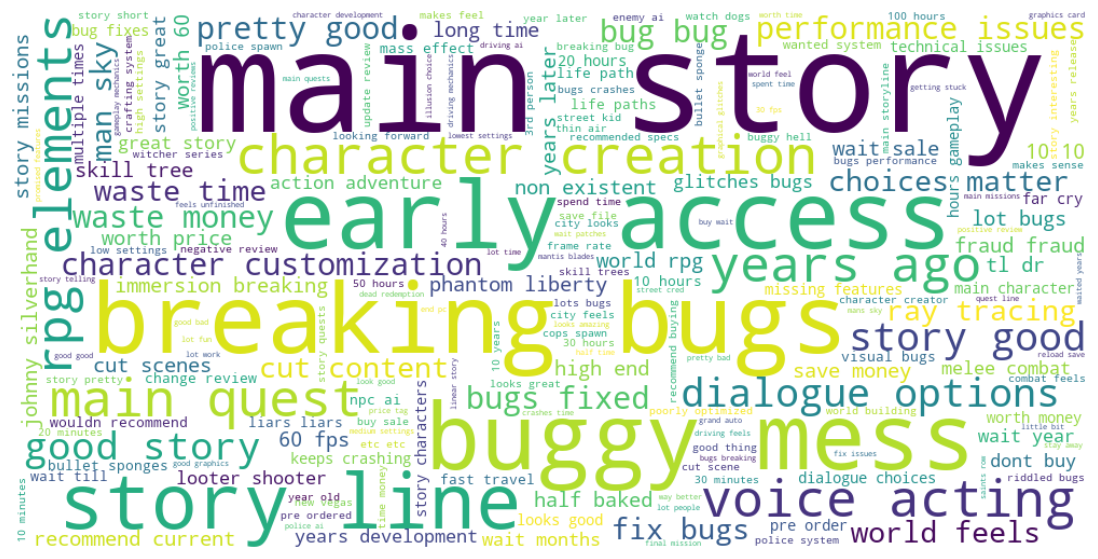

In [109]:
# Remove these phrases to not show on the wordcloud
phrases_to_remove = {
    "open world",
    "bugs glitches",
    "bugs bugs",
    "night city",
    "current state",
    "trash trash"
}

bigrams_filtered = [
    (phrase, count)
    for phrase, count in bigrams
    if phrase not in phrases_to_remove
]

# Bigrams to a dictionary
bigram_freq = dict(bigrams_filtered)

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(bigram_freq)

# Display
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

We have more descriptive topics like "wait sale", "waste money", "save money", or "immersion breaking", etc. It's clear that there are at least a few topics we can group them into. Let's also look at the trigrams while we're here:

#### Trigrams

In [112]:
# Get trigrams
vectorizer = CountVectorizer(
    stop_words=stop_words,
    ngram_range=(3,3),
)

X = vectorizer.fit_transform(
    negative_reviews["Review"]
)

counts = X.sum(axis=0).A1

trigrams = sorted(
    zip(vectorizer.get_feature_names_out(), counts),
    key=lambda x: x[1],
    reverse=True
)

trigrams[:10]

[('trash trash trash', 736),
 ('bugs bugs bugs', 449),
 ('bug bug bug', 415),
 ('open world rpg', 369),
 ('fraud fraud fraud', 334),
 ('recommend current state', 314),
 ('liars liars liars', 254),
 ('main story line', 246),
 ('bugs performance issues', 148),
 ('enemies bullet sponges', 137)]

These trigrams are much more negative. We'll update our phrases to remove variable with the unhelpful trigrams. We do have the term "enemies bullet sponges" which suggest that enemies feel like they have too much health, and "bugs performance issues" which relate to an unoptimized gaming experience. Let's look at the wordcloud:

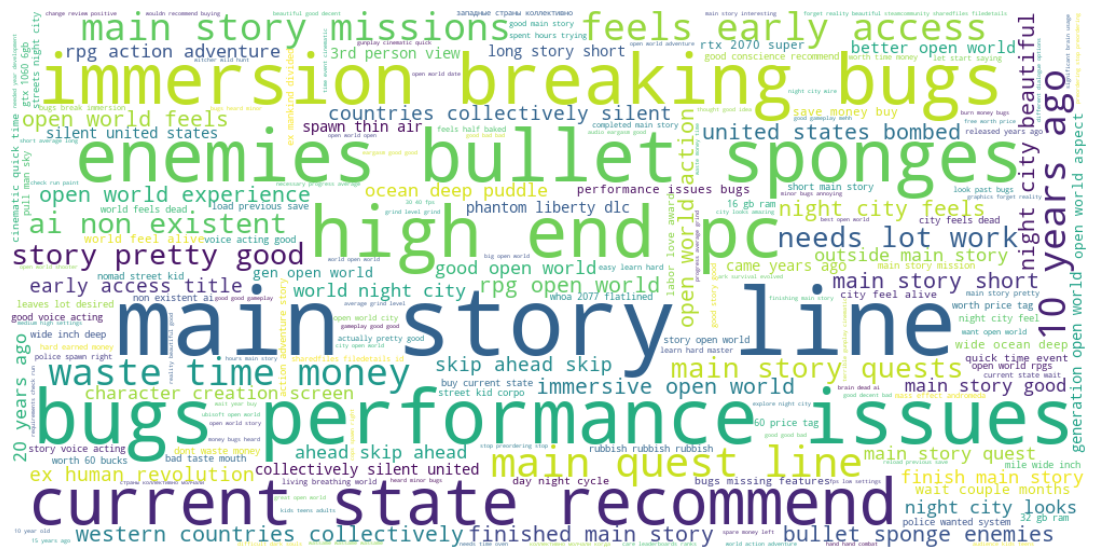

In [114]:
# Remove these phrases to not show on the wordcloud
phrases_to_remove = {
    "bugs bugs bugs",
    "recommend current state",
    "fraud fraud fraud",
    "open world rpg",
    "etc etc etc",
    "bla bla bla",
    "liars liars liars",
    "trash trash trash",
    "crash crash crash",
    "hate hate hate",
    "brokenits brokenits brokenits",
    "iti hate iti",
    "hate iti hate",
    "bug bug bug"
}

trigrams_filtered = [
    (phrase, count)
    for phrase, count in trigrams
    if phrase not in phrases_to_remove
]

# Trigrams into a dictionary
trigram_freq = dict(trigrams_filtered)

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(trigram_freq)

# Display
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

After filtering out the more unhelpful terms, we see a clearer picture of certain issues within the negative reviews. We have phrases like "bugs performace issues", "enemies bullet sponges", or "immersion breaking bugs" that clearly state certain issues players have with the game.

#### Interpretation and Analysis

Based on these findings, we see that there are a few topics we can look into when it comes to NLP and clustering. With phrases like "bugs performance issues", "enemies bullet sponges", or "immersion breaking bugs" for the trigrams, and "wait sale", "waste money", "save money" from the bigrams, it's clear that there are at least problems with performance issues, immersion, enemy health balancing, and pricing. These findings support Option C, the complaint analysis, as there are clear topics we can further analyze and group into to find out why players leave negative reviews and which ones need the most attention.

### Summary / Final Recommendation

Overall, the findings most strongly supports **Option C, which is to analyze negative Steam reviews to identify and prioritize recurring player concerns**. The EDA shows that negative reviews are more prevalent to those players with lower playtime, while positive reviews tend to come from players with more playtime. However, purchase status doesn't quite show a noticeable relationship to whether or not a player recommends the game or not, meaning that players' dissatisfaction for the game is not primarily explained by whether players got the game for free or not. The findings also show that negative reviews are generally longer than positive reviews, meaning that these provide more detailed text that can be used to identify the reasons behind player dissatisfactions with the game.

The review timeline shows that negative reviews were the most common during launch and major releases, followed by decreases after subsequent patches and hotfixes. This provides some support for **Option B**, as communication, responses, and fixes to the problems after these complaints may have contributed to player satisfaction. However, the data that was provided cannot confirm this as we don't have the information about developer communication or player exposure to announcements.

**Option A**, which is to increase advertising to attract newer players, is the least supported by the EDA> Although negative reviews generally decrease over time, the data doesn't show that attracting more players would address why players leave negative reviews. In fact, the concentration of negative reviews among the lower-playtime players suggests that players encounter problems early onto their gaming experience. Bringing in more players before understanding these problems could result in exposing this new playbase to the same issues.

**Option C** shows to be the best next step as it addresses the information we need the most: why players are dissastified. Initial NLP analysis found recurring phrases that relates to performance, bugs, immersion, enemy balancing, and pricing. By grouping and comparing these phrases from the negative reviews, Kosima Production will be able to find out what the major pain points/complaints are from the playbase, and determine which issues should receive the highest priority.

## Short Progress Report (MILESTONE 1)

Went through the data extensively. Changing my approach to the assignment from:
> for Option A, I plan to look at newer-player reviews (lower playtime etc.) and see what the sentiment is, while for Option B, I plan to look at older-player reviews (inverse of above). For option C, using NLP to figure out common words that the negative reviews have.

to a more holistic view of the data and drawing conclusions from each of these parts:
1. Timeline of the Reviews (looking at the dates to figure out if there are any trends in reviews at certain times)
2. Player Characteristics (looking at reviewers' statistics, their playtime and whether or not they received the game for free and compare it to their rating)
3. Review Characteristics (looking into review length, how helpful other people find their review, and general correlations between features)
4. Negative Review Text Processing (looking to see if there are any glaring common themes in the negative reviews to strictly see if Option C is viable)

Based on my findings from the EDA:
- Review sentiment: Negative reviews are more concentrated among players with lower playtime, while recommended reviews tend to come from players with higher playtime. Purchase status doesn't show a noticeable difference in recommendation outcomes.
- Review characteristics: Negative reviews tend to be longer than positive reviews, providing more detailed text that can be analyzed for recurring concerns. There are no strong observable correlations between playtime, helpfulness votes, and review length.
- Review timeline: Negative reviews are most prominent around the game's launch and major releases, all while negative reviews generally decrease after the following patches and hotfixes. This suggests that addressing problems may be associated with improved player sentiment, although the dataset doesn't have enough information to confirm that communication or patches directly caused these changes.
- Initial text analysis: Common words and phrases in negative reviews suggest recurring concerns related to bugs, performance, immersion, enemy balancing, and value/pricing. These show that negative reviews contain complaint themes that we can group up.

See above for the final recommendation.

For Phase 2, I will be taking an unsupervised approach. I'll be converting the negative reviews to numerical text representations and cluster it based on the similarities. Will use TD-IDF clustering.

## Phase 2: Data Science Implementation

> Assuming Kosima Production proceeds with Option C, group the English-language negative reviews according to their underlying complaint themes. The analysis should not begin with a predefined list of issue categories. Instead, the themes should be discovered from similarities in the language used in the reviews.
>
> After creating the groups, compare them using the number of reviews, percentage of negative reviews, median player playtime, review length, helpfulness votes, purchase status, and reviewer experience. Use these comparisons to determine which complaint themes should receive the highest priority.

We will be continuing onto Phase 2 with the intent of using TD-IDF and K-Means Clustering.

### Preprocess Text

We will re-preprocess our text in order to prepare it for TD-IDF and K-Means Clustering. Once again, we'll get all of the negative reviews that are not empty:

In [124]:
phase2 = df[
    (df["Rating"] == "Not Recommended") &
    (df["Review"].notna())
].copy()

phase2[["Review", "Hours Played"]].head()

,Review,Hours Played
3,"Bigot developerTo clarify, I got this game fro...",86.1
6,I paid $60 for this...,19.3
17,what the ♥♥♥♥,24.3
37,I waited 1 year to buy 3080 Ti so i can play t...,44.0
58,It's ♥♥♥♥ even after updates,66.9


We update our stopwords from scratch as I play around with the output. I found that these were the ones that gave the most useful outputs.

In [126]:
stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "game", "games",
    "play", "played",
    "playing", "get", "got", "one",
    "would", "could", "also",
    # "galore", "mantis blades",
    # "futuristic", "nor",
    # , "red",
    # "cd", "cdpr", "projekt", "cd projekt",
    # "cd projekt red", "projekt red",
    # "cyberpunk", "cyberpunk 2077", "2077",
    # "reddit", "youtube", "www", "com", 
    # "http", "https", "deus", "theft",
    # "gta", "fallout"
}

stop_words = stop_words.union(custom_stopwords)

negation_words = {
    "no", "nor", "not", "never", "neither"
}

stop_words = stop_words - negation_words

Slight change from our old `preprocess` function that created a list to instead create a string instead of an object:

In [128]:
def preprocess_text(text):
    # Insert space between lowercase-uppercase transitions
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Split into words
    words = text.split()
    
    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [129]:
phase2["Clean Review"] = phase2["Review"].apply(preprocess_text)
phase2["Clean Review"]

3                            bigot developer clarify friend
6                                                      paid
17                                                         
37        waited year buy ti normally realize u romance ...
58                                             even updates
                                ...                        
365320    great story garbage combat system bought disco...
365355    type bullet sponges enemies paper thing player...
365359                                          cyberglitch
365375    boring honestly ive playeing minutes minutes hard
365377    unplayable since car combat update hours new s...
Name: Clean Review, Length: 50234, dtype: object

Let's just quickly take a look at the distribution of the cleaned reviews:

In [131]:
phase2["Clean Review"].str.split().str.len().describe()

count    50234.000000
mean        43.007047
std         81.801516
min          0.000000
25%          4.000000
50%         14.000000
75%         44.000000
max        921.000000
Name: Clean Review, dtype: float64

I'll omit the ones that are short (<3) because these ones don't hold as much value.

In [139]:
phase2["Clean Word Count"] = (
    phase2["Clean Review"].str.split().str.len()
)

phase2_cluster = phase2[
    phase2["Clean Word Count"] >= 3
].copy()

In [140]:
print("Original negative English reviews:", len(phase2))
print("Reviews used for clustering:", len(phase2_cluster))

Original negative English reviews: 50234
Reviews used for clustering: 40902


We shaved off around 10000 reviews for clustering. Let's just double check what our clean reviews look like:

In [144]:
phase2_cluster[
    ["Review", "Clean Review"]
].head(10)

,Review,Clean Review
3,"Bigot developerTo clarify, I got this game fro...",bigot developer clarify friend
37,I waited 1 year to buy 3080 Ti so i can play t...,waited year buy ti normally realize u romance ...
89,Still unplayable on my PC at the lowest settin...,still unplayable pc lowest settings performanc...
91,Whoa! Cyberpunk 2077 has flatlined.,whoa cyberpunk flatlined
96,I use an unconventional keyboard binding layou...,use unconventional keyboard binding layout usi...
124,After playing this game over night i can certa...,night certainly say unfinished product filled ...
125,Stop CHEATING on player.EDIT: CD Project Red d...,stop cheating player edit cd project red lie p...
132,Why not let me change the ♥♥♥♥♥♥♥ keybindings....,not let change keybindings never dont allow ch...
146,Not as immersive as teasers and trailers made ...,not immersive teasers trailers made seem hones...
147,Review split to reflect progress10 Dec 20 This...,review split reflect progress dec looks amazin...


Looks good! Let's also check what our most common words are before we cluster.

In [147]:
all_words = " ".join(
    phase2_cluster["Clean Review"]
).split()

word_counts = Counter(all_words)

word_counts.most_common(30)

[('not', 35566),
 ('like', 24058),
 ('no', 18575),
 ('even', 17426),
 ('story', 17364),
 ('bugs', 17112),
 ('still', 12833),
 ('good', 12153),
 ('really', 12086),
 ('time', 11886),
 ('world', 10954),
 ('much', 8870),
 ('cyberpunk', 8205),
 ('many', 7681),
 ('character', 7662),
 ('bad', 7254),
 ('hours', 6886),
 ('make', 6664),
 ('feels', 6616),
 ('way', 6503),
 ('cdpr', 6460),
 ('city', 6395),
 ('feel', 6318),
 ('better', 6271),
 ('first', 5862),
 ('ai', 5861),
 ('nothing', 5843),
 ('fun', 5777),
 ('people', 5772),
 ('lot', 5746)]

### TD-IDF

We will continue with TD-IDF. I decided to limit the ngrams to bigrams as setting the max to 3 resulted in worse results. I had tested multiple values for `min_df` and `max_df` and found that `min_df = 5` and `max_df = 0.90` yielded the most useful clusters.

In [151]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90
)

X_tfidf = vectorizer.fit_transform(
    phase2_cluster["Clean Review"]
)

print(X_tfidf.shape)
print(X_tfidf.nnz)

(40902, 71627)
2582803


We went from 52000 entries to almost 41000 entries. 71169 features with only 2.57 million non zero values. Let's just quickly take a look at some of these features:

In [153]:
features = vectorizer.get_feature_names_out()

# Removing terms that I see show up very frequently that have no use to us
features_to_remove = {
    # "galore", "bug bug", "bug bug bug", 
    # "ms dos", "mantis blades", "futuristic",
    # "evelyn judy", "eve", "butt", "mommy"
}

keep = ~np.isin(features, list(features_to_remove))

X_tfidf_clean = X_tfidf[:, keep]

features_clean = features[keep]

print(X_tfidf.shape)
print(X_tfidf_clean.shape)

print(
    np.random.choice(features_clean, 50, replace=False)
)

(40902, 71627)
(40902, 71627)
['rpg full' 'recommending want' 'thats im' 'portions' 'cant fix'
 'develops' 'even continue' 'dev years' 'mean really' 'hmg' 'equip new'
 'paths nomad' 'go sale' 'hard never' 'world ie' 'read shards'
 'least another' 'rpg advertised' 'many dialogues' 'gonna wait' 'mostly'
 'time believing' 'skillpoints' 'top still' 'medium still' 'say matter'
 'fk cdpr' 'certain scenes' 'enemies walk' 'scripted driving'
 'fence getting' 'dialogue voice' 'felt linear' 'hated' 'beyond anything'
 'sale patches' 'story lore' 'glitches random' 'gender' 'full refund'
 'matter drive' 'windowed' 'practically unplayable' 'red think'
 'radio tower' 'listening' 'non reactive' 'no know' 'sometimes npcs'
 'super immersive']


### Clustering

We look at K-means clustering by conducting the elbow test and silhouette checking.

In [156]:
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_tfidf)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_tfidf_clean, labels)
    )

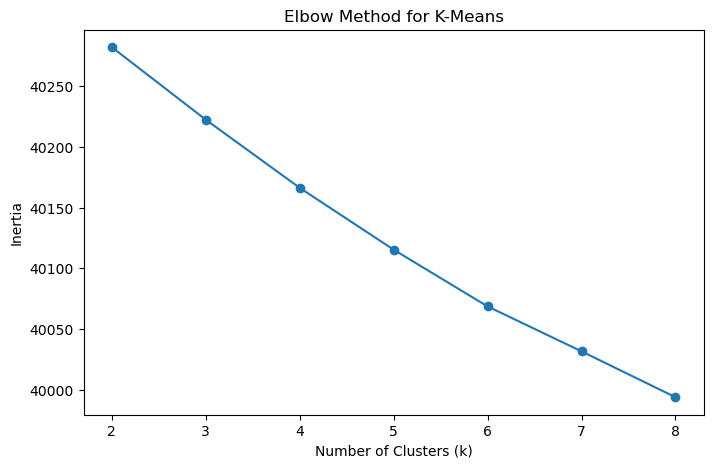

In [157]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

No clear elbow, but it seems like the inertia drops off the most at `k = 7`.

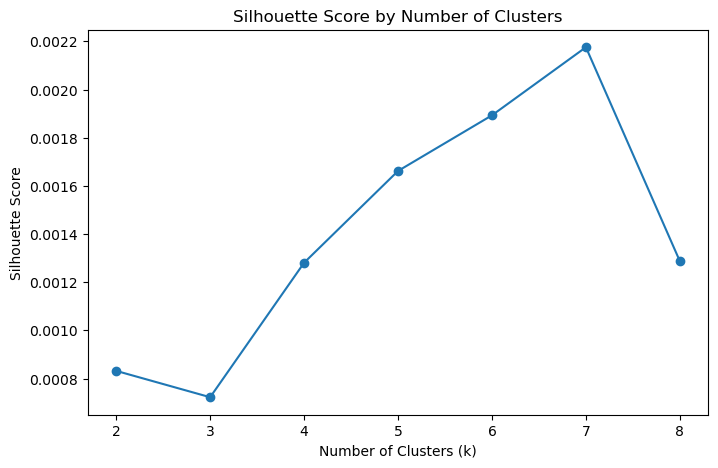

In [158]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.show()

This graph shows that `k = 7` has the greatest value in silhouette score. However, these values are still quite low, meaning that there's a lot of overlap between the complaint themes/clusters. This is probably due to the fact that these reviews can have the same topics in the same review. However, the model only assigns one topic to a review. This is one of our limitations with this method.

### Testing of K Values

#### k = 7

Based on the elbow method and the silhouette score, we'll investigate `k = 7` first.

In [163]:
kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

phase2_cluster["Cluster_k7"] = kmeans.fit_predict(X_tfidf_clean)

phase2_cluster["Cluster_k7"].value_counts().sort_index()

Cluster_k7
0    23645
1     1056
2     4225
3     8931
4     1707
5      746
6      592
Name: count, dtype: int64

In [164]:
terms = vectorizer.get_feature_names_out()

for cluster_num in range(kmeans.n_clusters):
    
    centroid = kmeans.cluster_centers_[cluster_num]
    
    top_indices = centroid.argsort()[-20:][::-1]
    
    top_terms = terms[top_indices]
    
    print(f"\nCluster {cluster_num}:")
    print(", ".join(top_terms))


Cluster 0:
not, still, like, even, no, good, crashes, time, buy, story, bad, years, cdpr, hours, bug, update, really, refund, fix, wait

Cluster 1:
worth, not worth, not, price, worth money, money, worth price, full, full price, worth full, still, bugs, wait, sale, story, time, even, buy, worth time, good

Cluster 2:
bugs, many, many bugs, still, not, glitches, breaking, full bugs, wait, even, story, full, bugs glitches, recommend, fix, breaking bugs, fixed, good, bugs bugs, lot

Cluster 3:
not, like, story, no, world, even, really, good, feels, character, much, bugs, time, city, feel, open, cyberpunk, main, side, open world

Cluster 4:
buggy, buggy mess, mess, still buggy, still, buggy hell, not, hell, even, story, unfinished, years, wait, buy, good, crashes, like, year, boring, really

Cluster 5:
money, waste, waste money, money back, waste time, back, time, want money, time money, not, want, give money, dont, dont waste, buy, refund, even, money time, give, still

Cluster 6:
crashi

In [165]:
for cluster_num in range(7):
    print(f"\n===== CLUSTER {cluster_num} =====")
    
    reviews = phase2_cluster[
        phase2_cluster["Cluster_k7"] == cluster_num
    ]["Review"]
    
    print(
        reviews.sample(
            min(10, len(reviews)),
            random_state=42
        ).to_string(index=False)
    )


===== CLUSTER 0 =====
25 years as a gamer.... never been so...... com...
My game is literally more broken now with the n...
this game needed another 2 years of dev timeoh ...
                           All style no substance.
braindead AI, bland story, the only rpg element...
2.0 is total graphic mess. It looks much worst ...
Just another generic boring rpg, this one was j...
80 CAD for a unfinished game.For the first 5m (...
after the newest update they dropped it just gi...
There are many loopholes in the game, which can...

===== CLUSTER 1 =====
Not a finished game. AI is terrible. Not even w...
Well...after all this time this game is still p...
you can polish a turd till its shinny, but all ...
                        Still trash, not worth it.
        Not worth 80 bucks (canadian) far from it.
Played over 40 hours, I'm completely bored by t...
Don't buy this trash.  Takes couples shots to k...
This game is over hyped, its merely a benchmark...
For the price its not worth it. I wa

We have a few related themes for the topics:

- [23645 reviews] Cluster 0: General Game Greivances
- [1056 reviews] Cluster 1: Pricing (`not worth`, `price`, `money`, `full price`, `sale`)
- [4225 reviews] Cluster 2: Bugs (`bugs`, `many bugs`, `glitches`, `breaking`)
- [8931 reviews] Cluster 3: Story (`story`, `world`, `character`, `city`, `open world`)
- [1707 reviews] Cluster 4: Unfinished/Buggy (`buggy`, `buggy mess`, `unfinished`, `wait`)
- [746 reviews] Cluster 5: Money/Refunds (`waste money`, `money`, `money back`, `refund`)
- [592 reviews] Cluster 6: Crashes (`crashing`, `keeps crashing`, `every minutes`, `unplayable`)

I see that we have small clusters (746 and 592 reviews). It even seems that our fifth cluster ("Money/Refunds") seems to just be a subset of our second one ("Pricing"). We'd probably end up combining these later. Although we do see some topics, let's take a look at other `k` values:

#### k = 6

To alleviate the small cluster issue, we can decrease the number of clusters.

In [168]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

phase2_cluster["Cluster_k6"] = kmeans.fit_predict(X_tfidf_clean)

phase2_cluster["Cluster_k6"].value_counts().sort_index()

Cluster_k6
0    22728
1     4866
2     1869
3     1040
4     1686
5     8713
Name: count, dtype: int64

In [169]:
terms = vectorizer.get_feature_names_out()

for cluster_num in range(kmeans.n_clusters):
    
    centroid = kmeans.cluster_centers_[cluster_num]
    
    top_indices = centroid.argsort()[-15:][::-1]
    
    top_terms = terms[top_indices]
    
    print(f"\nCluster {cluster_num}:")
    print(", ".join(top_terms))


Cluster 0:
not, still, like, even, no, good, time, buy, story, years, bad, cdpr, bug, money, hours

Cluster 1:
bugs, many, many bugs, not, still, glitches, wait, even, story, recommend, breaking, full bugs, good, fix, bugs glitches

Cluster 2:
crashes, every, crash, crashes every, time, minutes, still, update, even, not, unplayable, every time, every minutes, crashing, still crashes

Cluster 3:
worth, not worth, not, price, worth money, money, worth price, full, full price, worth full, still, wait, bugs, sale, time

Cluster 4:
buggy, buggy mess, mess, still buggy, still, buggy hell, not, hell, even, story, unfinished, years, wait, buy, good

Cluster 5:
not, like, story, no, world, really, even, good, character, feels, much, time, bugs, city, feel


This looks a bit better! With one less cluster, we now have all of our clusters above 1000 reviews. We still have a large ~22000-size cluster, but I found that throughout my testing, this is optimal for getting any decent topics in our clusters.

- [22728 reviews] Cluster 0: General Game Greivances
- [4866 reviews] Cluster 1: Bugs/Glitches (`bugs`, `many bugs`, `glitches`, `bugs glitches`, `fix`)
- [1869 reviews] Cluster 2: Crashes/Stability (`crashes`, `crash`, `every`, `minutes`, `unplayable`)
- [1040 reviews] Cluster 3: Pricing/Value (`worth`, `not worth`, `price`, `worth money`, `full price`, `sale`)
- [1686 reviews] Cluster 4: Unfinished/Buggy (`buggy`, `buggy mess`, `unfinished`, `still buggy`)
- [8713 reviews] Cluster 5: Story/World/Characters (`story`, `world`, `character`, `open world`)

There are four clear topics here:
- Bugs
- Crashes
- Pricing
- Story
  
All of which are actionable. Let's decrease `k` by 1 again to see:

#### k = 5

In [240]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

phase2_cluster["Cluster_k5"] = kmeans.fit_predict(X_tfidf_clean)

phase2_cluster["Cluster_k5"].value_counts().sort_index()

Cluster_k5
0    22125
1     4076
2     1750
3     8660
4     4291
Name: count, dtype: int64

In [241]:
terms = vectorizer.get_feature_names_out()

for cluster_num in range(kmeans.n_clusters):
    
    centroid = kmeans.cluster_centers_[cluster_num]
    
    top_indices = centroid.argsort()[-15:][::-1]
    
    top_terms = terms[top_indices]
    
    print(f"\nCluster {cluster_num}:")
    print(", ".join(top_terms))


Cluster 0:
still, like, even, no, crashes, time, not, good, years, story, update, hours, bug, cdpr, bad

Cluster 1:
not, worth, not worth, good, buy, price, not buy, still, money, even, not good, bad, story, recommend, bugs

Cluster 2:
buggy, buggy mess, still buggy, mess, still, buggy hell, not, hell, even, story, unfinished, years, wait, crashes, good

Cluster 3:
like, not, story, no, world, really, even, good, character, feels, much, bugs, time, city, feel

Cluster 4:
bugs, many, many bugs, still, glitches, not, full bugs, wait, even, breaking, story, full, bugs glitches, fix, recommend


This one still does better in fragmentation as there's less clusters, but I feel like it's too broad. We have the same broad cluster of general dissatisfaction to start off with, followed by money issues, crashes/being buggy/unfinished, story/world, and then finally more bugs/glitches. We effectively lost the pricing cluster, so maybe we won't go ahead with `k = 5`. Let's take a look at if we went the other way and increased the `k` by 1 instead:

#### k = 8

In [176]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

phase2_cluster["Cluster_k8"] = kmeans.fit_predict(X_tfidf_clean)

phase2_cluster["Cluster_k8"].value_counts().sort_index()

Cluster_k8
0      802
1    21855
2     1485
3     7524
4     1878
5      337
6     5372
7     1649
Name: count, dtype: int64

We have some small clusters once again. Let's just check them out:

In [177]:
terms = vectorizer.get_feature_names_out()

for cluster_num in range(kmeans.n_clusters):
    
    centroid = kmeans.cluster_centers_[cluster_num]
    
    top_indices = centroid.argsort()[-15:][::-1]
    
    top_terms = terms[top_indices]
    
    print(f"\nCluster {cluster_num}:")
    print(", ".join(top_terms))


Cluster 0:
many bugs, many, bugs, bugs bugs, way many, still many, glitches, still, not, way, bugs glitches, good, even, story, wait

Cluster 1:
not, bugs, still, like, good, no, story, even, bad, buy, years, cdpr, wait, bug, boring

Cluster 2:
worth, not worth, money, not, waste, waste money, worth money, price, money back, time, back, still, waste time, full, worth price

Cluster 3:
not, like, no, story, really, even, good, character, bugs, time, much, world, feels, feel, city

Cluster 4:
world, open, open world, not, story, rpg, like, no, ai, even, bugs, good, feels, cyberpunk, really

Cluster 5:
early access, access, early, like early, like, wait, feels, not, feels like, access title, bugs, title, years, released, still

Cluster 6:
crashes, crashing, fps, even, update, crash, cant, settings, time, unplayable, every, not, pc, still, launch

Cluster 7:
buggy, buggy mess, still buggy, mess, still, buggy hell, not, hell, even, years, unfinished, story, wait, good, buy


We have more fragmented clusters when `k = 8`. I immediately question Cluster 5 as it's very similar to the Cluster 7 topic of being "unfinished" as this one repeats the idea of `early` and `early access`. Otherwise, the rest of the topics are pretty similar to our previous ones we named. For the sake of clarity, I think we'll continue with `k = 6`.

#### Looking At Reviews at `k = 6`

In [223]:
for cluster_num in range(6):
    print(f"\n===== CLUSTER {cluster_num} =====")
    
    sample = phase2_cluster[
        phase2_cluster["Cluster_k6"] == cluster_num
    ]["Review"].sample(
        10,
        random_state=42
    )
    
    for review in sample:
        print("-", review)


===== CLUSTER 0 =====
- At first it was interesting but after the "prologue" its there is no decision making its basically "do it this way". not at all what i expected from one of the most awaited games.
- ive crashed 10 times in a row the arasaka hiest mission
- Just disappointing.CD Projekt RED should be ashamed to release this game in it's current state.
- Fantastique game, I ABSOLUTELY love it.Bad star ? Why?Im runing a 13900k, 64 of DDR5 6000mhz, SSD 990, andthe gamekeepcrashing.Its an awesome game tho, wouldnt recommend unless in sale.(NOT modded)
- played 4 hours and got to a spot where you control a memory, the game already made me feel slightly queasy and the dream section full on made me feel ill, so i quit. Wouldn't recommend at all if only because something about it made me sick and i cant possibly review something positively if it made me feel like that
- Still bugged as ♥♥♥♥, maybe even more than after 2/3 patch. Soft lock due to a multiplatform save then my save is dead

### Choice

I select `k = 6` as it had the best balance between cluster interpretability and fragmentation. `k = 5` had broader clusters that put the crashing and the general dissatisfaction in one cluster, while `k = 8` and `k = 7` had split related issues into smaller groups (eg. `early access` from `unfinished`. `k = 6` had the following themes that I was able to recognize:
1. bugs and glitches,
2. crashes and performance,
3. pricing and value,
4. buggy/unfinished experiences,
5. and story/world/character concerns.

Although a cluster remained relatively broad compared to the others, the other clusters are distinct enough to compare from one another.